# Machine Learning Based Atmospheric Data Analysis and Prediction
----------------------------------------------------------------
### Dataset: NASA POWER Atmospheric Data

**Tools Used:**
- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- Power BI

### Objective

To analyze historical atmospheric data, identify patterns and relationships
between atmospheric parameters, and use Machine Learning to predict
the temperature for the next hour.

**PART A - Data Cleaning**
----------------------
*we import libraries and clean the dataset*

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
df = pd.read_csv("nasa_power_data.csv")

In [4]:
df.head()

,YEAR,MO,DY,HR,ALLSKY_SFC_SW_DWN,T2M,RH2M,PS,WS10M,WD10M,WS50M,WD50M,RHOA,QV10M,CLOUD_AMT
0,2015,1,1,0,0.0,6.63,97.87,99.49,8.94,219.1,12.09,220.3,1.23,6.03,75.33
1,2015,1,1,1,0.0,6.94,97.85,99.46,8.81,223.0,12.00,223.7,1.23,6.15,97.73
2,2015,1,1,2,0.0,7.10,97.72,99.46,8.53,222.1,11.55,223.4,1.23,6.21,99.83
3,2015,1,1,3,0.0,7.07,97.82,99.35,8.06,216.2,10.80,216.8,1.23,6.21,99.78
4,2015,1,1,4,0.0,7.22,97.60,99.35,7.97,215.9,11.11,217.2,1.23,6.26,100.00


In [5]:
df.shape

(89376, 15)

In [6]:
df.columns

Index(['YEAR', 'MO', 'DY', 'HR', 'ALLSKY_SFC_SW_DWN', 'T2M', 'RH2M', 'PS',
       'WS10M', 'WD10M', 'WS50M', 'WD50M', 'RHOA', 'QV10M', 'CLOUD_AMT'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89376 entries, 0 to 89375
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   YEAR               89376 non-null  int64  
 1   MO                 89376 non-null  int64  
 2   DY                 89376 non-null  int64  
 3   HR                 89376 non-null  int64  
 4   ALLSKY_SFC_SW_DWN  89376 non-null  float64
 5   T2M                89376 non-null  float64
 6   RH2M               89376 non-null  float64
 7   PS                 89376 non-null  float64
 8   WS10M              89376 non-null  float64
 9   WD10M              89376 non-null  float64
 10  WS50M              89376 non-null  float64
 11  WD50M              89376 non-null  float64
 12  RHOA               89376 non-null  float64
 13  QV10M              89376 non-null  float64
 14  CLOUD_AMT          89376 non-null  float64
dtypes: float64(11), int64(4)
memory usage: 10.2 MB


In [8]:
df.describe()

,YEAR,MO,DY,HR,ALLSKY_SFC_SW_DWN,T2M,RH2M,PS,WS10M,WD10M,WS50M,WD50M,RHOA,QV10M,CLOUD_AMT
count,89376.000000,89376.000000,89376.000000,89376.000000,89376.000000,89376.000000,89376.000000,89376.000000,89376.000000,89376.000000,89376.000000,89376.000000,89376.000000,89376.000000,89376.000000
mean,2019.605263,6.430988,15.694683,11.500000,45.476864,7.339727,88.519036,97.354257,4.094834,203.353929,6.276144,203.824522,0.140718,5.300262,10.788014
std,2.942891,3.479562,8.801106,6.922225,314.004854,33.470024,37.419728,35.970810,33.004452,96.904868,33.136683,96.976088,32.763309,32.993491,257.572043
min,2015.000000,1.000000,1.000000,0.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000
25%,2017.000000,3.000000,8.000000,5.750000,0.000000,4.190000,84.990000,97.820000,3.080000,144.000000,5.050000,144.700000,1.200000,4.800000,49.630000
50%,2020.000000,6.000000,16.000000,11.500000,0.000000,8.110000,94.785000,98.670000,4.710000,226.900000,6.980000,227.500000,1.210000,6.160000,86.690000
75%,2022.000000,9.000000,23.000000,17.250000,155.577500,12.420000,97.580000,99.350000,6.720000,269.100000,9.110000,269.625000,1.230000,7.700000,99.090000
max,2025.000000,12.000000,31.000000,23.000000,883.350000,30.890000,100.000000,102.140000,19.650000,359.900000,25.690000,359.900000,1.300000,17.950000,100.000000


In [9]:
df.isnull().sum()

YEAR                 0
MO                   0
DY                   0
HR                   0
ALLSKY_SFC_SW_DWN    0
T2M                  0
RH2M                 0
PS                   0
WS10M                0
WD10M                0
WS50M                0
WD50M                0
RHOA                 0
QV10M                0
CLOUD_AMT            0
dtype: int64

In [10]:
(df == -999).sum()

YEAR                    0
MO                      0
DY                      0
HR                      0
ALLSKY_SFC_SW_DWN    5400
T2M                    96
RH2M                   96
PS                     96
WS10M                  96
WD10M                  96
WS50M                  96
WD50M                  96
RHOA                   96
QV10M                  96
CLOUD_AMT            5400
dtype: int64

In [11]:
df = df.replace(-999, np.nan)

In [12]:
df.isnull().sum()

YEAR                    0
MO                      0
DY                      0
HR                      0
ALLSKY_SFC_SW_DWN    5400
T2M                    96
RH2M                   96
PS                     96
WS10M                  96
WD10M                  96
WS50M                  96
WD50M                  96
RHOA                   96
QV10M                  96
CLOUD_AMT            5400
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df = df.drop_duplicates()

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df["DateTime"] = pd.to_datetime(
    dict(
        year=df["YEAR"],
        month=df["MO"],
        day=df["DY"],
        hour=df["HR"]
    )
)

In [17]:
df[["DateTime", "YEAR", "MO", "DY", "HR"]].head()

,DateTime,YEAR,MO,DY,HR
0,2015-01-01 00:00:00,2015,1,1,0
1,2015-01-01 01:00:00,2015,1,1,1
2,2015-01-01 02:00:00,2015,1,1,2
3,2015-01-01 03:00:00,2015,1,1,3
4,2015-01-01 04:00:00,2015,1,1,4


In [18]:
df = df.sort_values("DateTime")

In [19]:
df = df.reset_index(drop = True)

In [20]:
df[["DateTime"]].head(10)

,DateTime
0,2015-01-01 00:00:00
1,2015-01-01 01:00:00
2,2015-01-01 02:00:00
3,2015-01-01 03:00:00
4,2015-01-01 04:00:00
5,2015-01-01 05:00:00
6,2015-01-01 06:00:00
7,2015-01-01 07:00:00
8,2015-01-01 08:00:00
9,2015-01-01 09:00:00


In [21]:
df = df.rename(columns={
    "T2M": "Temperature",
    "RH2M": "Humidity",
    "PS": "Pressure",
    "WS10M": "WindSpeed_10m",
    "WD10M": "WindDirection_10m",
    "WS50M": "WindSpeed_50m",
    "WD50M": "WindDirection_50m",
    "RHOA": "AirDensity",
    "QV10M": "SpecificHumidity",
    "CLOUD_AMT": "CloudAmount",
    "ALLSKY_SFC_SW_DWN": "SolarRadiation"
})

In [22]:
df.columns

Index(['YEAR', 'MO', 'DY', 'HR', 'SolarRadiation', 'Temperature', 'Humidity',
       'Pressure', 'WindSpeed_10m', 'WindDirection_10m', 'WindSpeed_50m',
       'WindDirection_50m', 'AirDensity', 'SpecificHumidity', 'CloudAmount',
       'DateTime'],
      dtype='object')

In [23]:
df = df[
    [
        "DateTime",
        "Temperature",
        "Humidity",
        "Pressure",
        "WindSpeed_10m",
        "WindDirection_10m",
        "WindSpeed_50m",
        "WindDirection_50m",
        "AirDensity",
        "SpecificHumidity",
        "CloudAmount",
        "SolarRadiation"
    ]
]

In [24]:
df.head()

,DateTime,Temperature,Humidity,Pressure,WindSpeed_10m,WindDirection_10m,WindSpeed_50m,WindDirection_50m,AirDensity,SpecificHumidity,CloudAmount,SolarRadiation
0,2015-01-01 00:00:00,6.63,97.87,99.49,8.94,219.1,12.09,220.3,1.23,6.03,75.33,0.0
1,2015-01-01 01:00:00,6.94,97.85,99.46,8.81,223.0,12.00,223.7,1.23,6.15,97.73,0.0
2,2015-01-01 02:00:00,7.10,97.72,99.46,8.53,222.1,11.55,223.4,1.23,6.21,99.83,0.0
3,2015-01-01 03:00:00,7.07,97.82,99.35,8.06,216.2,10.80,216.8,1.23,6.21,99.78,0.0
4,2015-01-01 04:00:00,7.22,97.60,99.35,7.97,215.9,11.11,217.2,1.23,6.26,100.00,0.0


In [25]:
df.isnull().sum()

DateTime                0
Temperature            96
Humidity               96
Pressure               96
WindSpeed_10m          96
WindDirection_10m      96
WindSpeed_50m          96
WindDirection_50m      96
AirDensity             96
SpecificHumidity       96
CloudAmount          5400
SolarRadiation       5400
dtype: int64

In [26]:
df = df.dropna(subset = ["Temperature"])

In [27]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].median()
)

In [28]:
df.isnull().sum()

DateTime             0
Temperature          0
Humidity             0
Pressure             0
WindSpeed_10m        0
WindDirection_10m    0
WindSpeed_50m        0
WindDirection_50m    0
AirDensity           0
SpecificHumidity     0
CloudAmount          0
SolarRadiation       0
dtype: int64

In [29]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nStart Date:")
print(df["DateTime"].min())

print("\nEnd Date:")
print(df["DateTime"].max())

Rows: 89280
Columns: 12

Start Date:
2015-01-01 00:00:00

End Date:
2025-03-08 23:00:00


**PART B — Exploratory Data Analysis**
-------------------------------------
*Now we start analyzing the atmospheric data.*

In [30]:
df["Temperature"].describe()

count    89280.000000
mean         8.421813
std          5.596260
min        -10.080000
25%          4.210000
50%          8.110000
75%         12.420000
max         30.890000
Name: Temperature, dtype: float64

**Temperature Over Time**

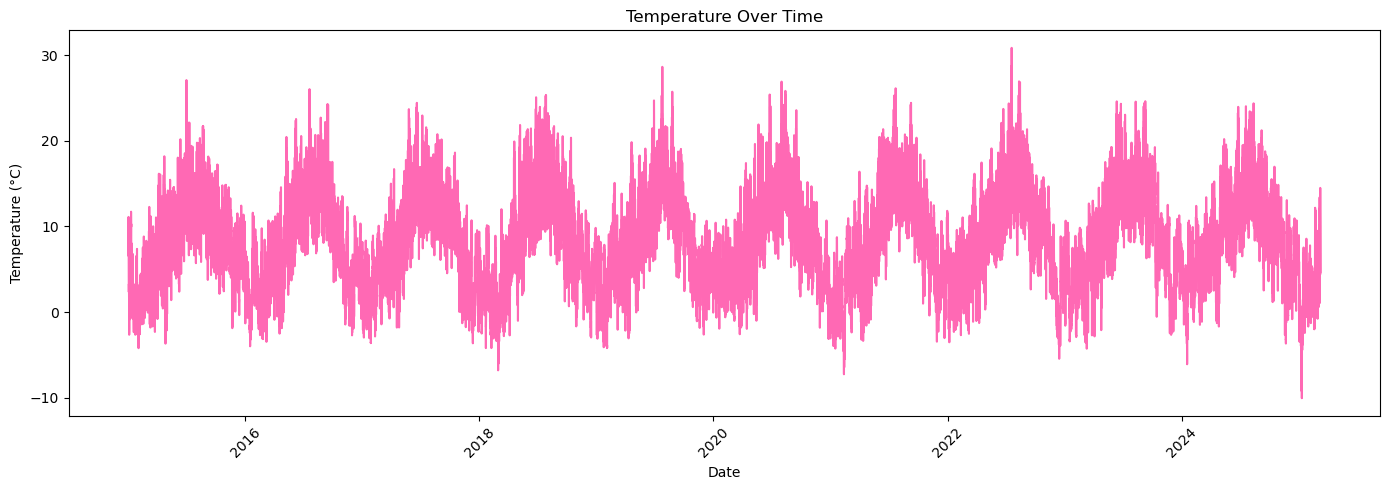

In [31]:
plt.figure(figsize=(14,5))

plt.plot(
    df["DateTime"],
    df["Temperature"],color = 'hotpink'
)

plt.title("Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Solar Radiation**

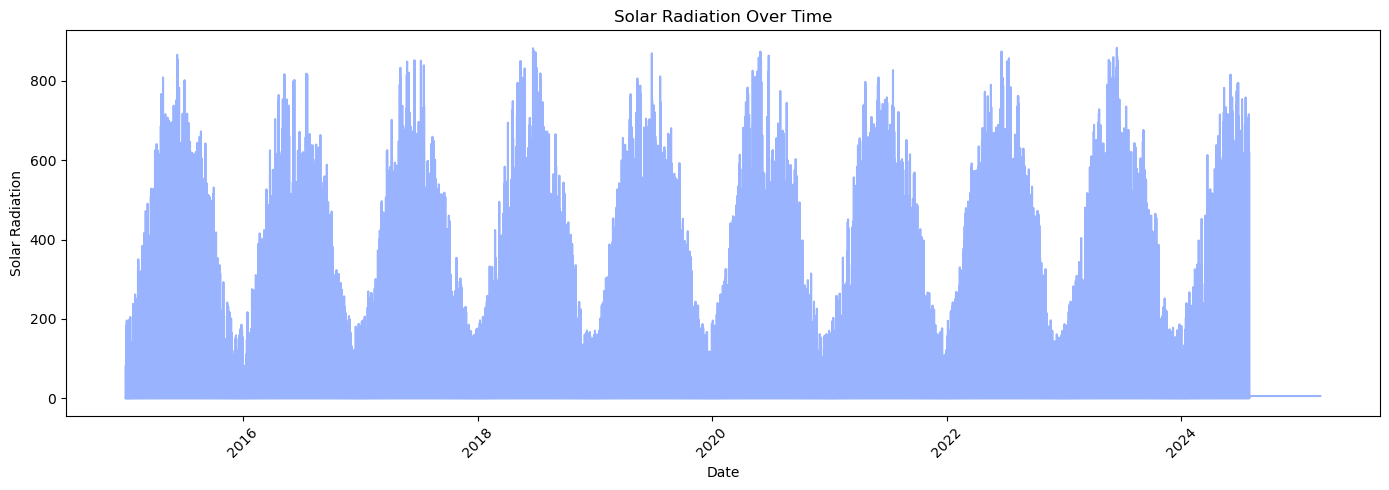

In [32]:
plt.figure(figsize=(14,5))

plt.plot(
    df["DateTime"],
    df["SolarRadiation"],color = '#99b3ff'
)

plt.title("Solar Radiation Over Time")
plt.xlabel("Date")
plt.ylabel("Solar Radiation")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Wind Speed**

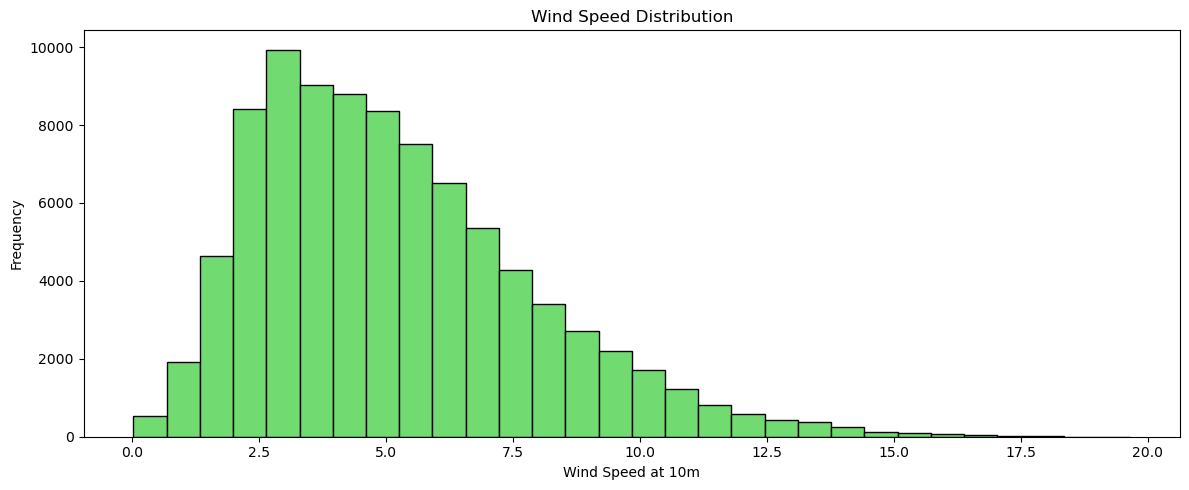

In [42]:
plt.figure(figsize=(12,5))

plt.hist(
    df["WindSpeed_10m"],color = '#71da71',edgecolor = 'black',
    bins=30
)

plt.title("Wind Speed Distribution")
plt.xlabel("Wind Speed at 10m")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

**Temperature vs Humidity**

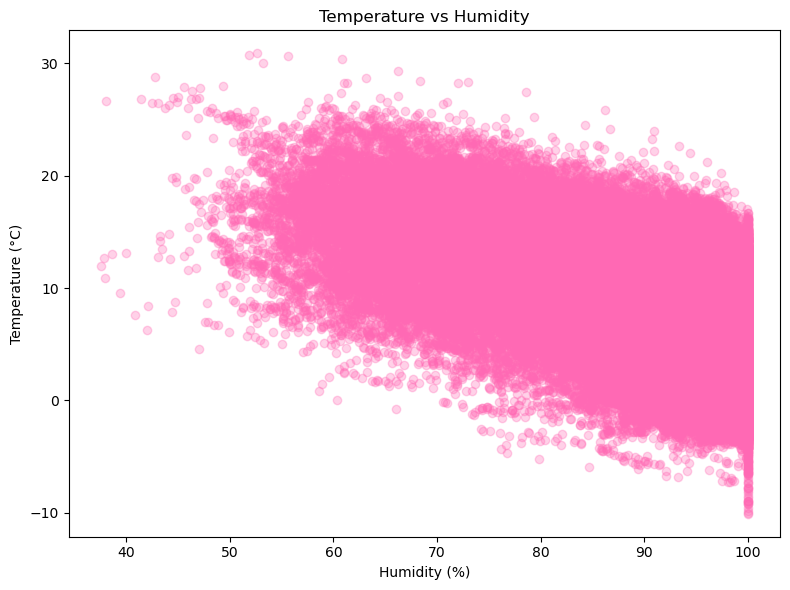

In [34]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Humidity"],
    df["Temperature"],color = 'hotpink',
    alpha=0.3
)

plt.title("Temperature vs Humidity")
plt.xlabel("Humidity (%)")
plt.ylabel("Temperature (°C)")

plt.tight_layout()
plt.show()

**Temperature vs Solar Radiation**

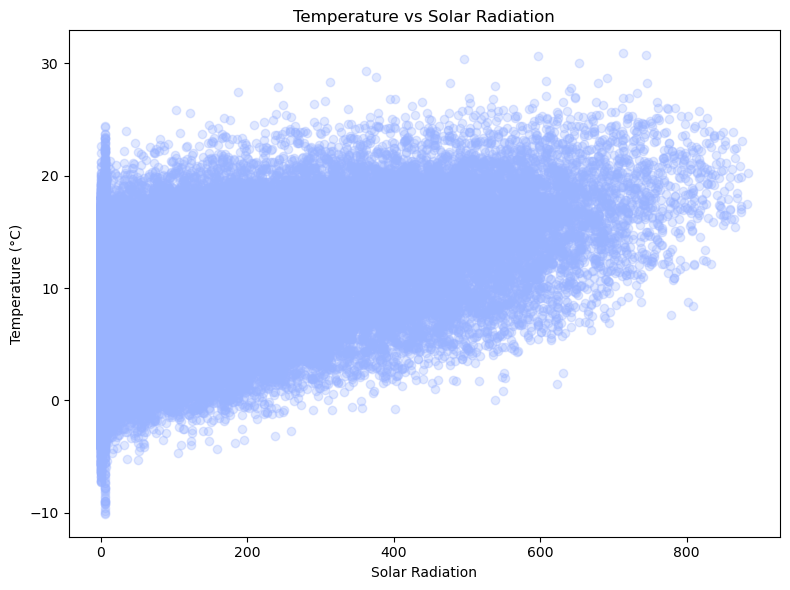

In [35]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["SolarRadiation"],
    df["Temperature"],color = '#99b3ff',
    alpha=0.3
)
plt.title("Temperature vs Solar Radiation")
plt.xlabel("Solar Radiation")
plt.ylabel("Temperature (°C)")

plt.tight_layout()
plt.show()

**Correlation Matrix**

In [36]:
corr_columns = [
    "Temperature",
    "Humidity",
    "Pressure",
    "WindSpeed_10m",
    "WindSpeed_50m",
    "AirDensity",
    "SpecificHumidity",
    "CloudAmount",
    "SolarRadiation"
]

correlation = df[corr_columns].corr()

correlation

,Temperature,Humidity,Pressure,WindSpeed_10m,WindSpeed_50m,AirDensity,SpecificHumidity,CloudAmount,SolarRadiation
Temperature,1.000000,-0.576277,0.068717,0.012040,-0.072466,-0.823288,0.877385,0.025261,0.522628
Humidity,-0.576277,1.000000,-0.141063,-0.086605,0.069492,0.330089,-0.140791,0.131328,-0.832997
Pressure,0.068717,-0.141063,1.000000,-0.362300,-0.360854,0.469146,-0.022292,-0.184941,0.112802
WindSpeed_10m,0.012040,-0.086605,-0.362300,1.000000,0.965134,-0.150218,-0.027057,0.103565,0.076879
WindSpeed_50m,-0.072466,0.069492,-0.360854,0.965134,1.000000,-0.111922,-0.040566,0.086709,-0.089321
AirDensity,-0.823288,0.330089,0.469146,-0.150218,-0.111922,1.000000,-0.819599,-0.103353,-0.290381
SpecificHumidity,0.877385,-0.140791,-0.022292,-0.027057,-0.040566,-0.819599,1.000000,0.100550,0.160579
CloudAmount,0.025261,0.131328,-0.184941,0.103565,0.086709,-0.103353,0.100550,1.000000,-0.173898
SolarRadiation,0.522628,-0.832997,0.112802,0.076879,-0.089321,-0.290381,0.160579,-0.173898,1.000000


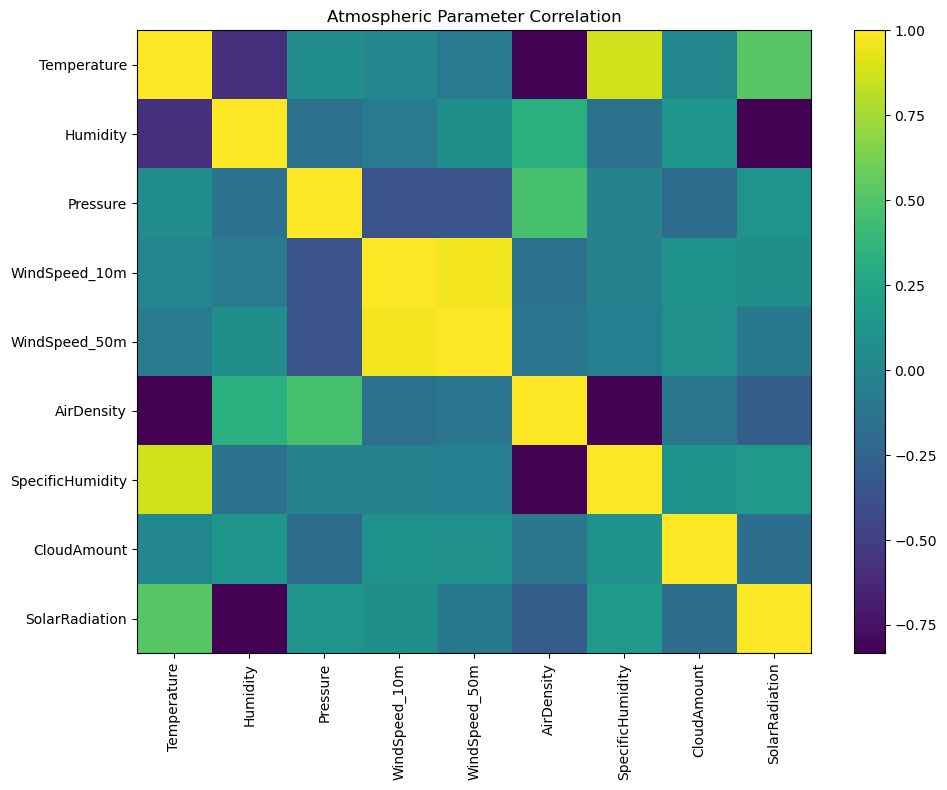

In [37]:
plt.figure(figsize=(10,8))

plt.imshow(
    correlation,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Atmospheric Parameter Correlation")

plt.tight_layout()
plt.show()

**PART C — Time-Based Analysis**
----------------------------
*This makes your project more interesting.*

In [38]:
df["Year"] = df["DateTime"].dt.year
df["Month"] = df["DateTime"].dt.month
df["Day"] = df["DateTime"].dt.day
df["Hour"] = df["DateTime"].dt.hour
df["DayOfWeek"] = df["DateTime"].dt.dayofweek

In [39]:
df[
    [
        "DateTime",
        "Year",
        "Month",
        "Day",
        "Hour",
        "DayOfWeek"
    ]
].head()

,DateTime,Year,Month,Day,Hour,DayOfWeek
0,2015-01-01 00:00:00,2015,1,1,0,3
1,2015-01-01 01:00:00,2015,1,1,1,3
2,2015-01-01 02:00:00,2015,1,1,2,3
3,2015-01-01 03:00:00,2015,1,1,3,3
4,2015-01-01 04:00:00,2015,1,1,4,3


In [40]:
hourly_temperature = df.groupby(
    "Hour"
)["Temperature"].mean()

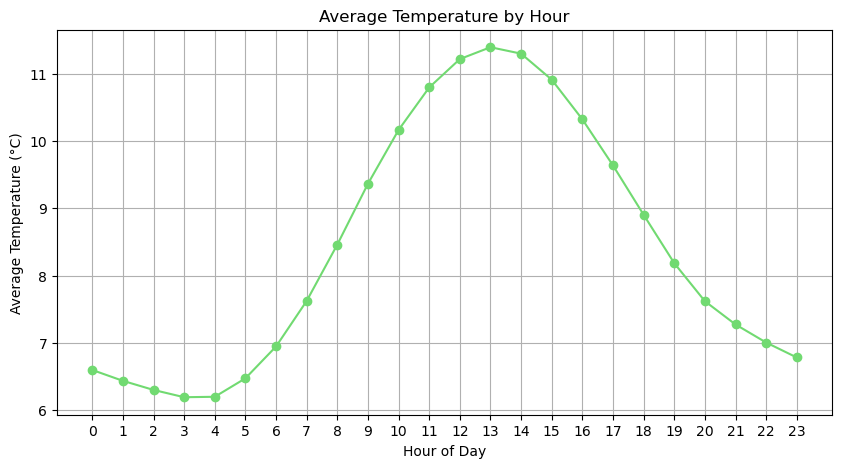

In [45]:
plt.figure(figsize=(10,5))

plt.plot(
    hourly_temperature.index,
    hourly_temperature.values,
    marker="o",color = '#71da71'
)

plt.title("Average Temperature by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Temperature (°C)")

plt.xticks(range(24))

plt.grid()
plt.show()

In [46]:
monthly_temperature = df.groupby(
    "Month"
)["Temperature"].mean()

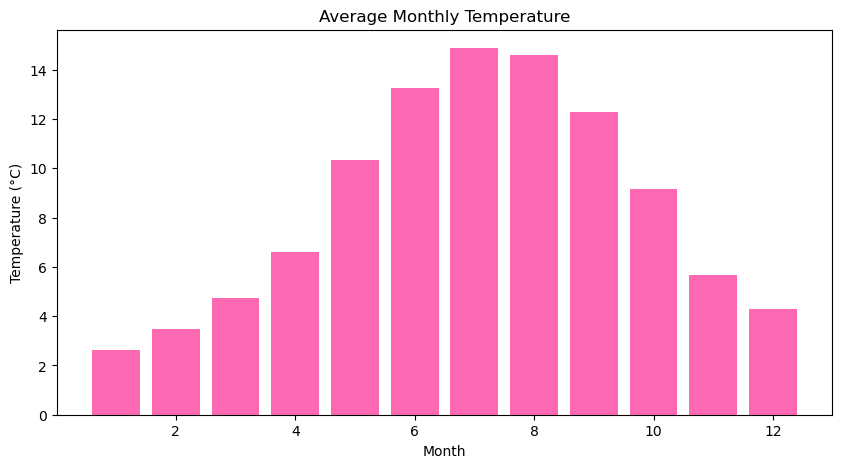

In [48]:
plt.figure(figsize=(10,5))

plt.bar(
    monthly_temperature.index,
    monthly_temperature.values,color = 'hotpink'
)

plt.title("Average Monthly Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")

plt.show()

**PART D — MACHINE LEARNING**
-------------------------
*Now we move to the main objective.*

In [49]:
df["NextHourTemperature"] = df[
    "Temperature"
].shift(-1)

In [50]:
df[
    [
        "DateTime",
        "Temperature",
        "NextHourTemperature"
    ]
].head(10)

,DateTime,Temperature,NextHourTemperature
0,2015-01-01 00:00:00,6.63,6.94
1,2015-01-01 01:00:00,6.94,7.10
2,2015-01-01 02:00:00,7.10,7.07
3,2015-01-01 03:00:00,7.07,7.22
4,2015-01-01 04:00:00,7.22,7.45
5,2015-01-01 05:00:00,7.45,7.69
6,2015-01-01 06:00:00,7.69,8.03
7,2015-01-01 07:00:00,8.03,8.28
8,2015-01-01 08:00:00,8.28,8.38
9,2015-01-01 09:00:00,8.38,8.57


In [51]:
df = df.dropna(
    subset=["NextHourTemperature"]
)

In [52]:
features = [
    "Temperature",
    "Humidity",
    "Pressure",
    "WindSpeed_10m",
    "WindDirection_10m",
    "WindSpeed_50m",
    "WindDirection_50m",
    "AirDensity",
    "SpecificHumidity",
    "CloudAmount",
    "SolarRadiation",
    "Hour",
    "Month"
]

In [53]:
target = "NextHourTemperature"

In [54]:
X = df[features]
y = df[target]

In [55]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (89279, 13)
y shape: (89279,)


**PART E — Time-Series Train/Test Split**
---------------------------------------

In [56]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [57]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 71423
Testing samples: 17856


**PART F — MODEL 1: LINEAR REGRESSION**
-----------------------------------

In [58]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

LinearRegression()

In [59]:
linear_prediction = linear_model.predict(
    X_test
)

In [60]:
linear_mae = mean_absolute_error(
    y_test,
    linear_prediction
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_prediction
    )
)

linear_r2 = r2_score(
    y_test,
    linear_prediction
)

print("Linear Regression")
print("-----------------------")

print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

Linear Regression
-----------------------
MAE : 0.4603978332681932
RMSE: 0.6245606011624765
R²  : 0.9872856900111328


**PART G — MODEL 2: RANDOM FOREST**
---------------------------------

In [62]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [63]:
rf_prediction = rf_model.predict(
    X_test
)

In [64]:
rf_mae = mean_absolute_error(
    y_test,
    rf_prediction
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_prediction
    )
)

rf_r2 = r2_score(
    y_test,
    rf_prediction
)

print("Random Forest")
print("-----------------------")

print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest
-----------------------
MAE : 0.3323486671146953
RMSE: 0.46571221752611497
R²  : 0.9929306596701702


**PART H — MODEL COMPARISON**
------------------------------

In [65]:
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],

    "MAE": [
        linear_mae,
        rf_mae
    ],

    "RMSE": [
        linear_rmse,
        rf_rmse
    ],

    "R2": [
        linear_r2,
        rf_r2
    ]
})

model_results

,Model,MAE,RMSE,R2
0,Linear Regression,0.460398,0.624561,0.987286
1,Random Forest,0.332349,0.465712,0.992931


**PART I — ACTUAL VS PREDICTED**
-----------------------------

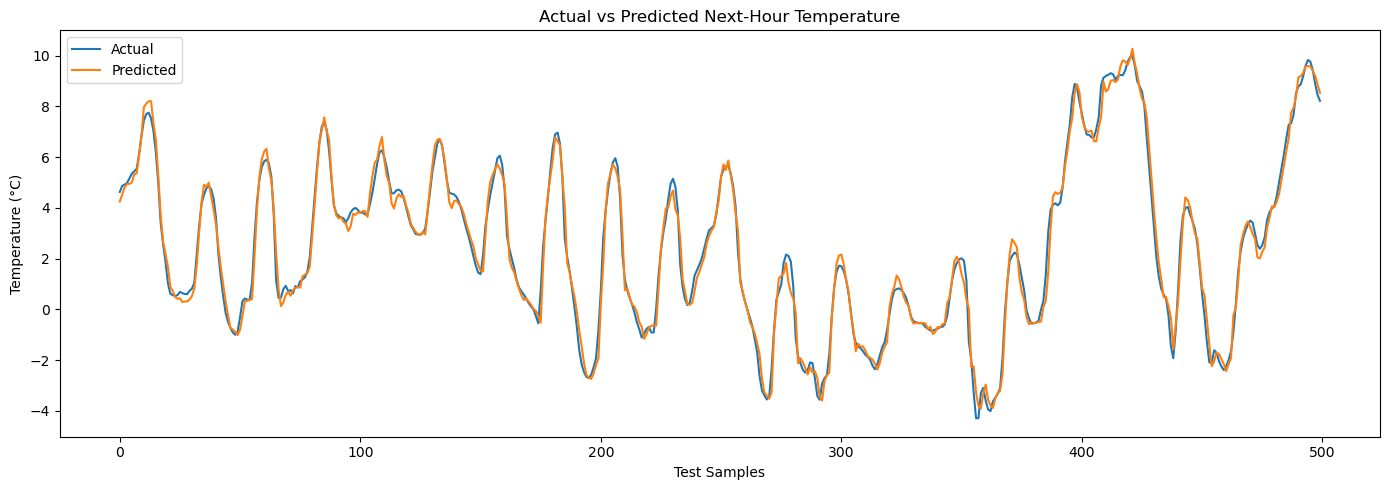

In [66]:
plt.figure(figsize=(14,5))

plt.plot(
    y_test.values[:500],
    label="Actual"
)

plt.plot(
    rf_prediction[:500],
    label="Predicted"
)

plt.title(
    "Actual vs Predicted Next-Hour Temperature"
)

plt.xlabel("Test Samples")
plt.ylabel("Temperature (°C)")

plt.legend()

plt.tight_layout()
plt.show()

**PART J — FEATURE IMPORTANCE**
-----------------------------

In [68]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

In [69]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

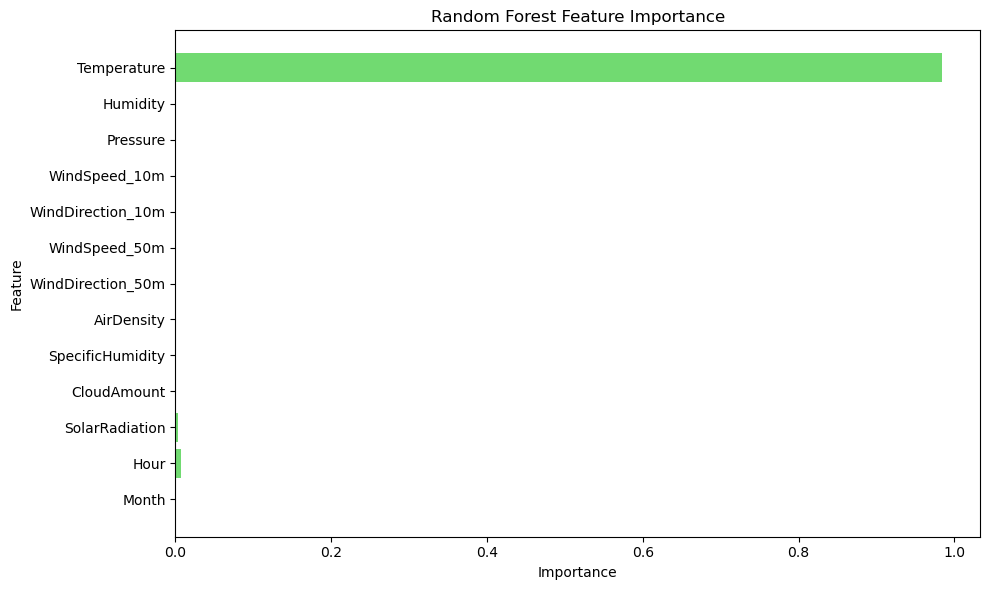

In [71]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"],color = '#71da71'
)

plt.title(
    "Random Forest Feature Importance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

**PART K — Create Prediction Dataset**
-----------------------------------

In [72]:
prediction_results = X_test.copy()

prediction_results["ActualTemperature"] = (
    y_test.values
)

prediction_results["PredictedTemperature"] = (
    rf_prediction
)

In [73]:
prediction_results.head()

,Temperature,Humidity,Pressure,WindSpeed_10m,WindDirection_10m,WindSpeed_50m,WindDirection_50m,AirDensity,SpecificHumidity,CloudAmount,SolarRadiation,Hour,Month,ActualTemperature,PredictedTemperature
71423,4.22,97.36,98.80,6.05,266.5,8.34,267.3,1.24,5.09,99.67,0.0,23,2,4.63,4.2558
71424,4.63,97.69,98.73,6.27,273.0,8.50,274.1,1.23,5.25,99.82,0.0,0,2,4.87,4.5176
71425,4.87,97.63,98.65,6.42,279.6,8.62,280.8,1.23,5.34,99.85,0.0,1,2,4.92,4.8167
71426,4.92,97.59,98.59,6.50,283.5,8.72,284.8,1.23,5.37,97.42,0.0,2,2,4.98,4.9404
71427,4.98,97.66,98.53,6.53,286.7,8.81,288.1,1.23,5.39,99.11,0.0,3,2,5.16,4.9497


In [74]:
prediction_results["DateTime"] = df[
    "DateTime"
].iloc[split_index:].values

In [75]:
prediction_results = prediction_results[
    [
        "DateTime",
        "ActualTemperature",
        "PredictedTemperature"
    ] + features
]

In [76]:
prediction_results.head()

,DateTime,ActualTemperature,PredictedTemperature,Temperature,Humidity,Pressure,WindSpeed_10m,WindDirection_10m,WindSpeed_50m,WindDirection_50m,AirDensity,SpecificHumidity,CloudAmount,SolarRadiation,Hour,Month
71423,2023-02-23 23:00:00,4.63,4.2558,4.22,97.36,98.80,6.05,266.5,8.34,267.3,1.24,5.09,99.67,0.0,23,2
71424,2023-02-24 00:00:00,4.87,4.5176,4.63,97.69,98.73,6.27,273.0,8.50,274.1,1.23,5.25,99.82,0.0,0,2
71425,2023-02-24 01:00:00,4.92,4.8167,4.87,97.63,98.65,6.42,279.6,8.62,280.8,1.23,5.34,99.85,0.0,1,2
71426,2023-02-24 02:00:00,4.98,4.9404,4.92,97.59,98.59,6.50,283.5,8.72,284.8,1.23,5.37,97.42,0.0,2,2
71427,2023-02-24 03:00:00,5.16,4.9497,4.98,97.66,98.53,6.53,286.7,8.81,288.1,1.23,5.39,99.11,0.0,3,2


**PART L — Save Files**
---------------------

In [77]:
df.to_csv(
    "cleaned_atmospheric_data.csv",
    index=False
)

In [78]:
prediction_results.to_csv(
    "atmospheric_predictions_powerbi.csv",
    index=False
)

In [80]:
model_results.to_csv(
    "model_comparison.csv",
    index=False
)

In [81]:
importance.to_csv(
    "feature_importance.csv",
    index=False
)